In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import sys
import os
sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz, simulate_henon
from core_ntsa.noise_tools import add_white_noise, add_colored_noise
from core_ntsa.metrics import calculate_kantz_divergence, extract_kantz_slopes, calculate_kantz_derivative

lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)
clean_x = lorenz_data[0]

x_white_noise = add_white_noise(clean_x, snr_db=40.0)
x_clored_noise = add_colored_noise(clean_x, color='pink', snr_db=30.0)

Độ lệch chuẩn của tín hiệu (std): 7.8964
Đang khởi chạy thuật toán Kantz với cấu hình Epsilon tối ưu...
Hệ thống thiết lập Cửa sổ Theiler mặc định (w) = 32 bước



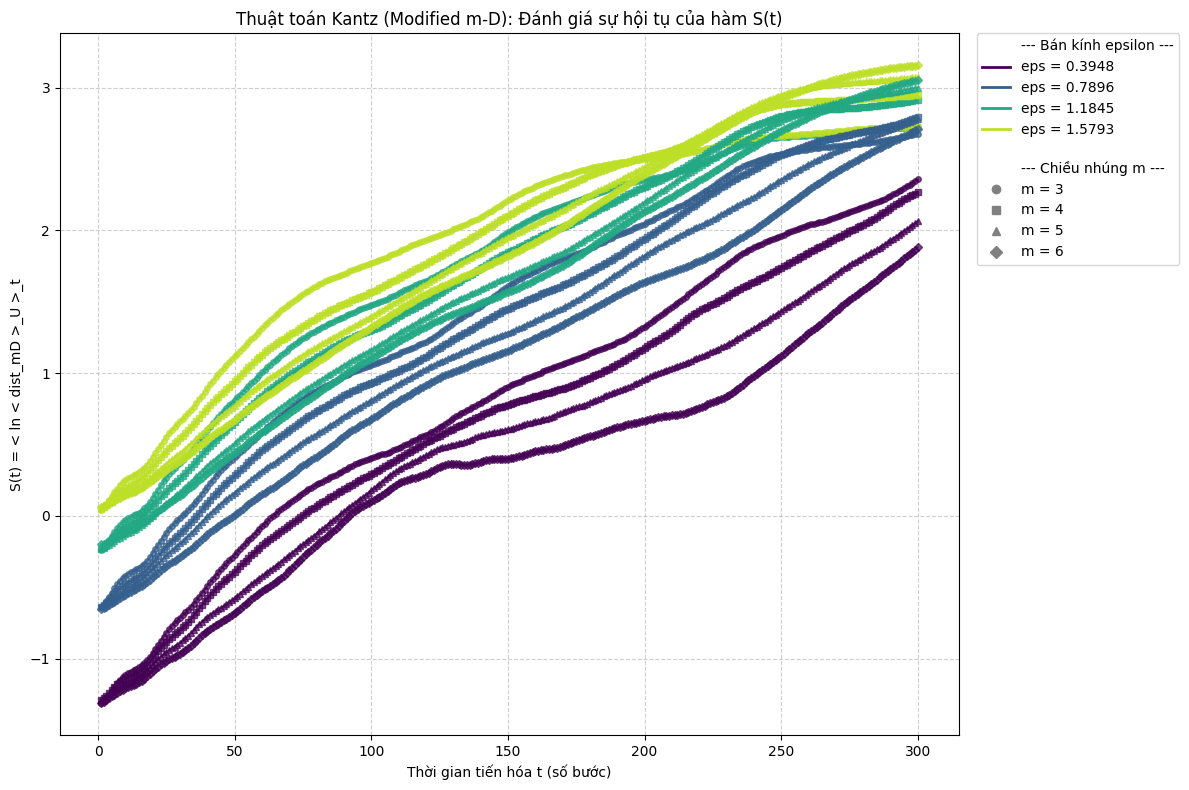

In [2]:
std_x = np.std(clean_x)
print(f"Độ lệch chuẩn của tín hiệu (std): {std_x:.4f}")

# 2. Khởi tạo các tham số Động lực học
delay_tau = 16
m_list = [3, 4, 5, 6]                  # Khảo sát xung quanh điểm tối ưu m=4

# Khởi tạo eps_list bằng các tỷ lệ phần trăm của Độ lệch chuẩn (ví dụ: 5%, 10%, 15%, 20%)
eps_factors = [0.05, 0.10, 0.15, 0.2]
eps_list = [factor * std_x for factor in eps_factors]

t_evolution = 300

# 3. Thực thi cỗ máy Kantz
print("Đang khởi chạy thuật toán Kantz với cấu hình Epsilon tối ưu...")
t_steps_lorenz, results_kantz_lorenz = calculate_kantz_divergence(
    signal=clean_x,
    delay=delay_tau,
    m_list=m_list,
    eps_list=eps_list,
    t_max=t_evolution,
    w=None
)

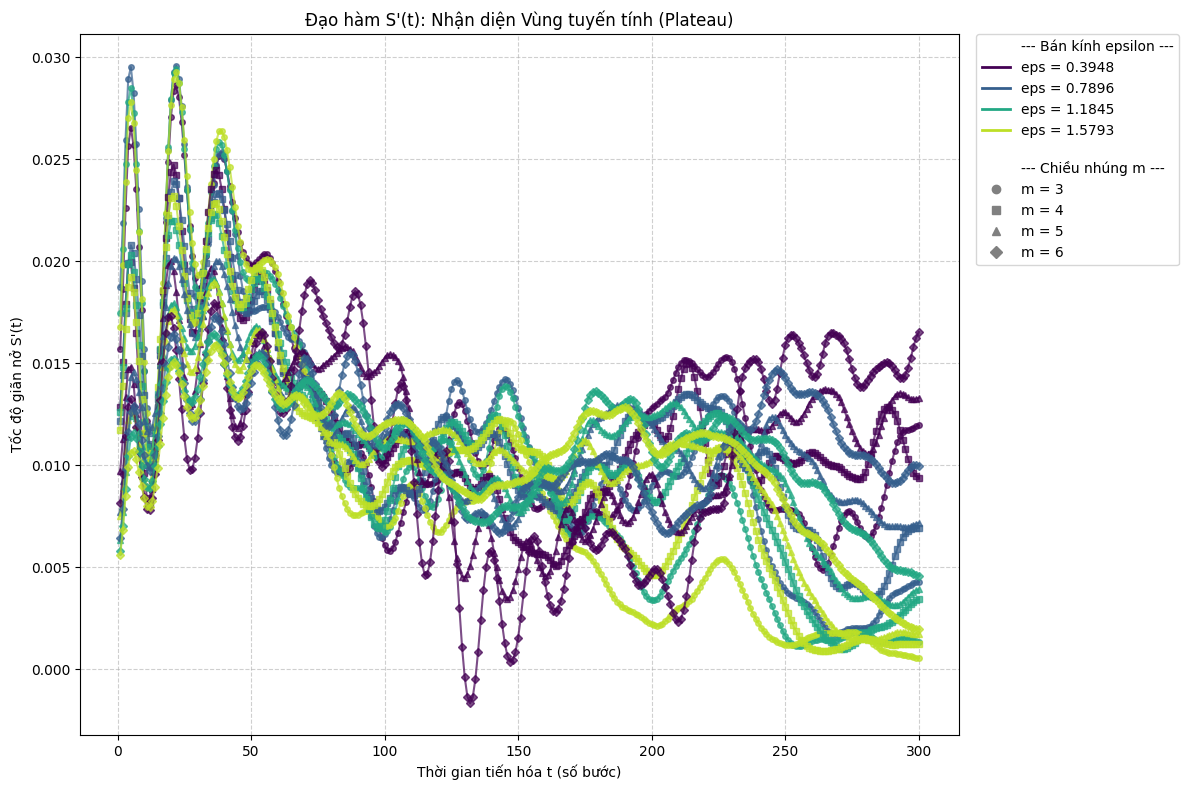

In [3]:
# Gọi hàm với mặc định làm mượt bằng cửa sổ 3 bước
derivatives_dict = calculate_kantz_derivative(t_steps_lorenz, results_kantz_lorenz, smoothing_window=3)

In [4]:
slopes_data = extract_kantz_slopes(
    t_steps=t_steps_lorenz,
    results_kantz=results_kantz_lorenz,
    fit_start=100,
    fit_end=180, 
    sampling_rate=100
)

--- KẾT QUẢ TRÍCH XUẤT LLE (t = 100 đến 180, Fs = 100 Hz) ---

>> Bán kính Epsilon = 0.3948
Chiều nhúng m   | lambda_1 (1/s)  | R^2       
------------------------------------------------
m=3             | 0.9775          | 0.9952    
m=4             | 0.8229          | 0.9835    
m=5             | 0.6799          | 0.9730    
m=6             | 0.4653          | 0.9443    

>> Bán kính Epsilon = 0.7896
Chiều nhúng m   | lambda_1 (1/s)  | R^2       
------------------------------------------------
m=3             | 1.1113          | 0.9944    
m=4             | 1.0018          | 0.9965    
m=5             | 0.8974          | 0.9975    
m=6             | 0.8916          | 0.9949    

>> Bán kính Epsilon = 1.1845
Chiều nhúng m   | lambda_1 (1/s)  | R^2       
------------------------------------------------
m=3             | 1.0233          | 0.9961    
m=4             | 1.0489          | 0.9972    
m=5             | 0.9500          | 0.9964    
m=6             | 0.8923          | 0.9959 

Độ lệch chuẩn của tín hiệu (std): 7.8990
Đang khởi chạy thuật toán Kantz với cấu hình Epsilon tối ưu...
Hệ thống thiết lập Cửa sổ Theiler mặc định (w) = 32 bước



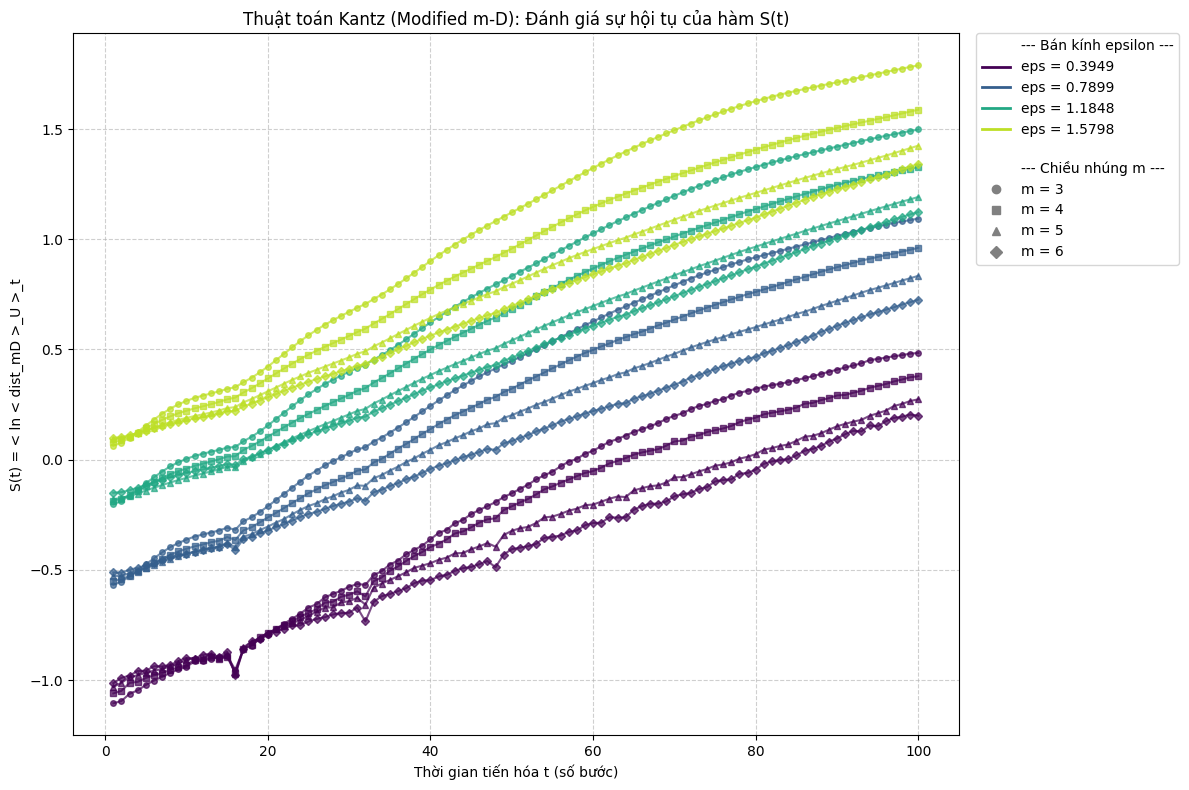

--- KẾT QUẢ TRÍCH XUẤT LLE (t = 80 đến 100, Fs = 100 Hz) ---

>> Bán kính Epsilon = 0.3949
Chiều nhúng m   | lambda_1 (1/s)  | R^2       
------------------------------------------------
m=3             | 0.8675          | 0.9939    
m=4             | 0.9451          | 0.9980    
m=5             | 1.2494          | 0.9974    
m=6             | 1.2955          | 0.9893    

>> Bán kính Epsilon = 0.7899
Chiều nhúng m   | lambda_1 (1/s)  | R^2       
------------------------------------------------
m=3             | 0.8972          | 0.9961    
m=4             | 1.0058          | 0.9950    
m=5             | 1.1785          | 0.9995    
m=6             | 1.3156          | 0.9976    

>> Bán kính Epsilon = 1.1848
Chiều nhúng m   | lambda_1 (1/s)  | R^2       
------------------------------------------------
m=3             | 0.8482          | 0.9978    
m=4             | 0.9513          | 0.9930    
m=5             | 1.1274          | 0.9997    
m=6             | 1.2419          | 0.9993  

In [6]:
std_x = np.std(x_white_noise)
print(f"Độ lệch chuẩn của tín hiệu (std): {std_x:.4f}")

# 2. Khởi tạo các tham số Động lực học
delay_tau = 16
m_list = [3, 4, 5, 6]                  # Khảo sát xung quanh điểm tối ưu m=4

# Khởi tạo eps_list bằng các tỷ lệ phần trăm của Độ lệch chuẩn (ví dụ: 5%, 10%, 15%, 20%)
eps_factors = [0.05, 0.10, 0.15, 0.2]
eps_list = [factor * std_x for factor in eps_factors]

t_evolution = 100

# 3. Thực thi cỗ máy Kantz
print("Đang khởi chạy thuật toán Kantz với cấu hình Epsilon tối ưu...")
t_steps_lorenz, results_kantz_lorenz = calculate_kantz_divergence(
    signal=x_white_noise,
    delay=delay_tau,
    m_list=m_list,
    eps_list=eps_list,
    t_max=t_evolution,
    w=None
)
slopes_data = extract_kantz_slopes(
    t_steps=t_steps_lorenz,
    results_kantz=results_kantz_lorenz,
    fit_start=80,
    fit_end=100, 
    sampling_rate=100
)

Độ lệch chuẩn của tín hiệu (std): 7.9236
Đang khởi chạy thuật toán Kantz với cấu hình Epsilon tối ưu...
Hệ thống thiết lập Cửa sổ Theiler mặc định (w) = 32 bước



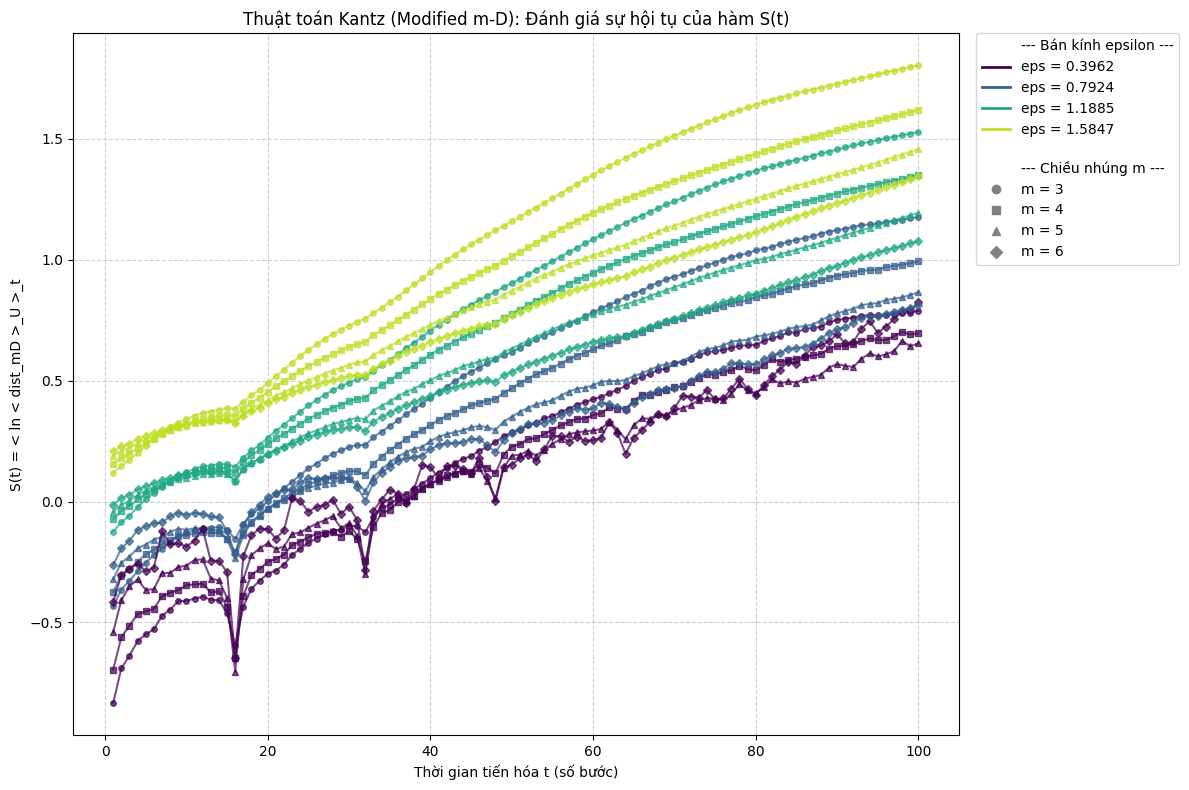

--- KẾT QUẢ TRÍCH XUẤT LLE (t = 80 đến 100, Fs = 100 Hz) ---

>> Bán kính Epsilon = 0.3962
Chiều nhúng m   | lambda_1 (1/s)  | R^2       
------------------------------------------------
m=3             | 0.6756          | 0.9401    
m=4             | 0.7487          | 0.9680    
m=5             | 1.0031          | 0.9590    
m=6             | 1.6299          | 0.9436    

>> Bán kính Epsilon = 0.7924
Chiều nhúng m   | lambda_1 (1/s)  | R^2       
------------------------------------------------
m=3             | 0.6930          | 0.9835    
m=4             | 0.7406          | 0.9876    
m=5             | 0.9655          | 0.9915    
m=6             | 1.2412          | 0.9834    

>> Bán kính Epsilon = 1.1885
Chiều nhúng m   | lambda_1 (1/s)  | R^2       
------------------------------------------------
m=3             | 0.8043          | 0.9970    
m=4             | 0.8436          | 0.9965    
m=5             | 0.9986          | 0.9991    
m=6             | 1.0999          | 0.9983  

In [7]:
std_x = np.std(x_clored_noise)
print(f"Độ lệch chuẩn của tín hiệu (std): {std_x:.4f}")

# 2. Khởi tạo các tham số Động lực học
delay_tau = 16
m_list = [3, 4, 5, 6]                  # Khảo sát xung quanh điểm tối ưu m=4

# Khởi tạo eps_list bằng các tỷ lệ phần trăm của Độ lệch chuẩn (ví dụ: 5%, 10%, 15%, 20%)
eps_factors = [0.05, 0.10, 0.15, 0.2]
eps_list = [factor * std_x for factor in eps_factors]

t_evolution = 100

# 3. Thực thi cỗ máy Kantz
print("Đang khởi chạy thuật toán Kantz với cấu hình Epsilon tối ưu...")
t_steps_lorenz, results_kantz_lorenz = calculate_kantz_divergence(
    signal=x_clored_noise,
    delay=delay_tau,
    m_list=m_list,
    eps_list=eps_list,
    t_max=t_evolution,
    w=None
)
slopes_data = extract_kantz_slopes(
    t_steps=t_steps_lorenz,
    results_kantz=results_kantz_lorenz,
    fit_start=80,
    fit_end=100, 
    sampling_rate=100
)

Độ lệch chuẩn của chuỗi Henon-X: 0.7150
Đang khởi chạy thuật toán Kantz trên hệ Hénon...


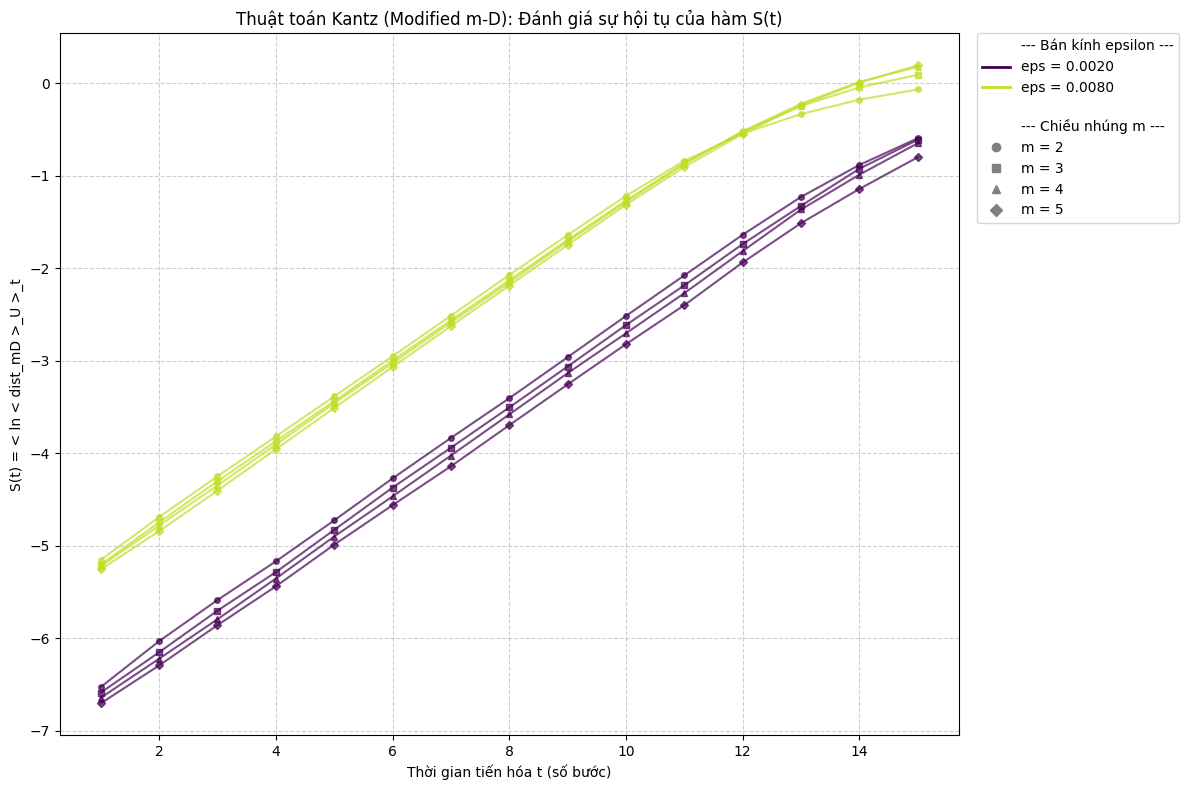

In [5]:
import numpy as np

# 1. Khởi tạo quỹ đạo hỗn loạn từ hệ Henon
trajectory = simulate_henon(n_iterations=3000, transient_drop=1000)

# Trong thực tế, ta chỉ quan sát được một biến vô hướng. Chọn trục X làm đại diện.
henon_x = trajectory[0, :]

# Tính độ lệch chuẩn làm mỏ neo cho bán kính epsilon
std_x = np.std(henon_x)
print(f"Độ lệch chuẩn của chuỗi Henon-X: {std_x:.4f}")

# 2. Thiết lập thông số Động lực học (Đặc thù cho Discrete Map)
# Thời gian rời rạc tiến từng bước một, độ trễ luôn tối ưu ở 1
delay_tau = 1 

# Hệ Henon có số chiều nội tại là 2, ta khảo sát quanh m=2
m_list = [2, 3, 4, 5] 

eps_list = [0.002, 0.008]

# Do tính rời rạc, quỹ đạo Henon bứt tốc phân kỳ hàm mũ cực kỳ khốc liệt.
# Chỉ cần khoảng 15-20 bước là hệ thống đã chạm vách bão hòa.
t_evolution = 15 

# Đối với bản đồ rời rạc không có quán tính hình học (không có sườn sóng liên tục),
# Cửa sổ Theiler có thể set về 0 (hoặc 1) để thuật toán không bị loại bỏ láng giềng oan.
theiler_window = 0 

# 3. Kích hoạt cỗ máy Kantz
print("Đang khởi chạy thuật toán Kantz trên hệ Hénon...")
t_steps, results_henon = calculate_kantz_divergence(
    signal=henon_x,
    delay=delay_tau,
    m_list=m_list,
    eps_list=eps_list,
    t_max=t_evolution,
    w=theiler_window
)

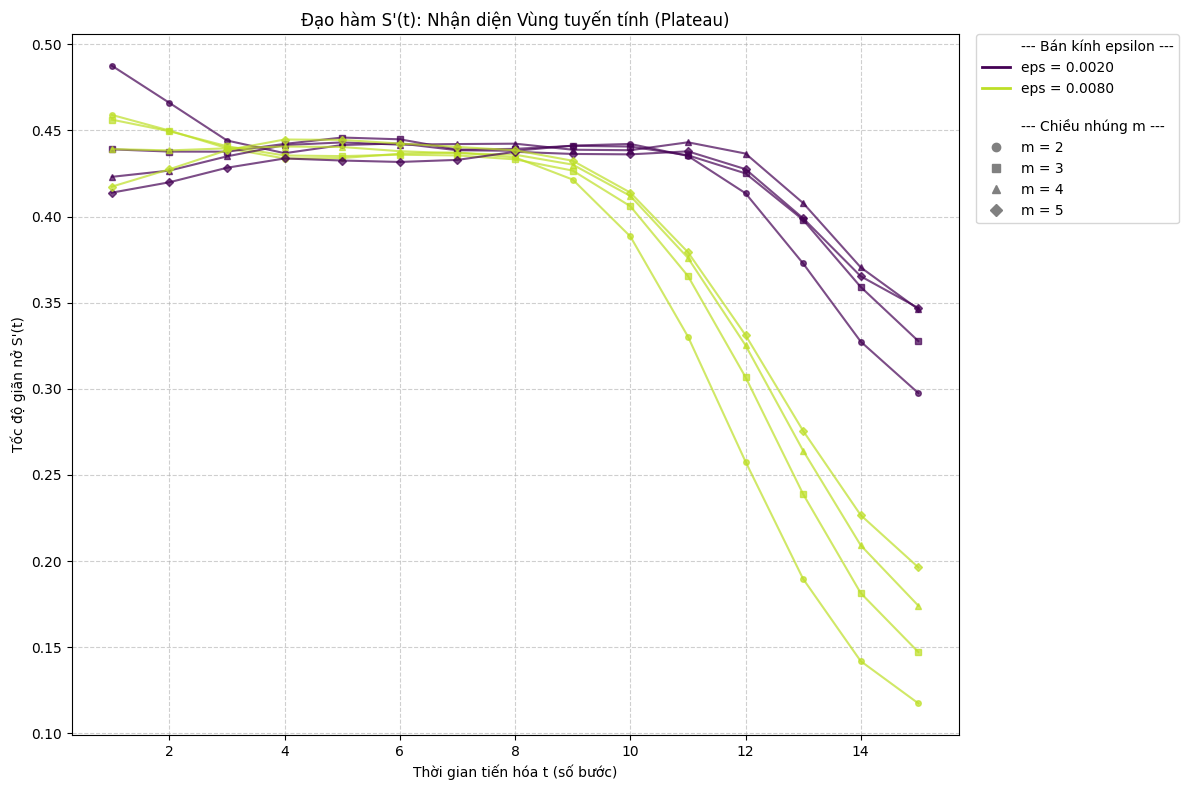

In [6]:
derivatives_dict_awake = calculate_kantz_derivative(t_steps, results_henon, smoothing_window=3)

In [7]:
fit_start_point = 4
fit_end_point = 8

slopes_data = extract_kantz_slopes(
    t_steps=t_steps,
    results_kantz=results_henon,
    fit_start=fit_start_point,
    fit_end=fit_end_point
)

--- KẾT QUẢ TRÍCH XUẤT LLE (t = 4 đến 8, Fs = 1.0 Hz) ---

>> Bán kính Epsilon = 0.0020
Chiều nhúng m   | lambda_1 (1/s)  | R^2       
------------------------------------------------
m=2             | 0.4418          | 0.9999    
m=3             | 0.4450          | 0.9998    
m=4             | 0.4425          | 1.0000    
m=5             | 0.4333          | 0.9999    

>> Bán kính Epsilon = 0.0080
Chiều nhúng m   | lambda_1 (1/s)  | R^2       
------------------------------------------------
m=2             | 0.4366          | 1.0000    
m=3             | 0.4356          | 1.0000    
m=4             | 0.4381          | 1.0000    
m=5             | 0.4424          | 1.0000    


### Sự khác biệt nền tảng giữa $\lambda$ lý thuyết và $\hat{\lambda}$ thực nghiệm

LLE (Largest Lyapunov Exponent) là một bất biến động lực học ở mức hệ thật, nhưng ước lượng LLE trong Phân tích chuỗi thời gian phi tuyến (NTSA) thì không bất biến theo nghĩa thực nghiệm. Cả hai mệnh đề này đều tồn tại song song và chính xác về mặt toán học.

#### 1. Trong lý thuyết hệ động lực: LLE là một bất biến
Xét hệ động lực liên tục:
$$\dot{x} = f(x)$$
hoặc hệ rời rạc:
$$x_{n+1} = F(x_n)$$

Phổ Lyapunov của hệ thống $\lambda_1 \ge \lambda_2 \ge \dots$ là một đại lượng nội tại của bộ hút (attractor). Nếu ta thực hiện một phép đổi tọa độ trơn (diffeomorphism) $y = h(x)$, thì về mặt tiệm cận:
$$\lambda_i^{(y)} = \lambda_i^{(x)}$$
Đó là lý do Lyapunov exponent được vinh danh là một **bất biến động lực học (dynamical invariant)**.

#### 2. Sự kết nối của Định lý Takens
Định lý nhúng Takens chỉ ra rằng: Nếu ta tái cấu trúc không gian pha từ một chuỗi vô hướng:
$$X(t) = [x(t), x(t+\tau), \dots, x(t+(m-1)\tau)]$$
với số chiều $m$ đủ lớn và ánh xạ nhúng tốt, thì bộ hút tái tạo sẽ tương đương hình học với bộ hút thật. Do đó, về mặt lý thuyết:
$$\lambda_{embed} = \lambda_{true}$$
Đây chính là cơ sở toán học để các thuật toán đo lường như Rosenstein hay Kantz ra đời.

#### 3. Sự phá vỡ trong NTSA thực nghiệm do tính hữu hạn
Tuy nhiên, trong NTSA thực tiễn, sự bất biến này bị phá vỡ bởi các ước lượng hữu hạn. Đại lượng tính toán thực tế là $\hat{\lambda}$ chứ không phải $\lambda$. Giá trị này là hàm phụ thuộc đa biến vào cấu hình thuật toán:
$$\hat{\lambda} = f(N, \tau, m, \epsilon, w, \text{noise}, \text{fit})$$

Chính vì vậy, $\hat{\lambda}$ không còn là một đại lượng bất biến. Chẳng hạn, trên cùng một hệ Lorenz, ta có thể thu được $\hat{\lambda} \approx 0.9$ hoặc $\hat{\lambda} \approx 1.5$ chỉ vì sự khác biệt trong bước thời gian sinh dữ liệu hoặc khoảng nội suy tuyến tính. Nếu $\hat{\lambda}$ thực sự bất biến thực nghiệm, những biến động này đã không thể xảy ra.

---

> **KẾT LUẬN CỐT LÕI:**
> 
> *Largest Lyapunov exponent là một bất biến của hệ động lực dưới các phép biến đổi trơn. Tuy nhiên, giá trị LLE được ước lượng trong NTSA từ chuỗi thời gian hữu hạn ($\hat{\lambda}$) không phải là một đại lượng bất biến thực nghiệm và có thể phụ thuộc đáng kể vào quá trình tái tạo không gian pha cũng như việc lựa chọn hyper-parameters. Đây là một trong những khác biệt nền tảng giữa lý thuyết hỗn loạn (chaos theory) và kỹ thuật phát hiện hỗn loạn (chaos detection).*